# Preparación de datos WO₃ para PUMA

Procesa los archivos **ASC** (PerkinElmer UV WinLab) de transmitancia de WO₃ sobre cuarzo  
a diferentes flujos de oxígeno, elimina el rango corrupto 836–860 nm, interpola,  
aplica filtro Savitzky–Golay y genera los archivos PUMA (`FNAME-dat.txt`).

| Muestra | Flujo O₂ | Espesor estimado |
|---------|----------|------------------|
| S2      | 10 sccm  | 73.000 nm        |
| S5      |  7 sccm  | 105.145 nm       |
| S8      |  5 sccm  | 136.586 nm       |

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter
from scipy.interpolate import PchipInterpolator, interp1d
import os

# ─── CONFIGURACIÓN GLOBAL ──────────────────────────────────────────────────────

SAMPLES = {
    "WO3_S2_10sccm": {
        "file"         : "WO3_datos_crudos/WO3_cuarzo_20260507_S2_10sccm_A.ASC",
        "thickness_nm" : 73.000,
        "label"        : "10 sccm – 73 nm",
        "color"        : "royalblue",
    },
    "WO3_S5_7sccm": {
        "file"         : "WO3_datos_crudos/WO3_cuarzo_20260507_S5_7sccm_A.ASC",
        "thickness_nm" : 105.145,
        "label"        : "7 sccm – 105.1 nm",
        "color"        : "darkorange",
    },
    "WO3_S8_5sccm": {
        "file"         : "WO3_datos_crudos/WO3_cuarzo_20260507_S8_5sccm_A.ASC",
        "thickness_nm" : 136.586,
        "label"        : "5 sccm – 136.6 nm",
        "color"        : "forestgreen",
    },
}

BAD_MIN = 836     # nm – inicio de zona corrupta
BAD_MAX = 860     # nm – fin de zona corrupta

# Rango para PUMA:
# - Límite inferior: 300 nm — incluye el borde de absorción del WO₃ (Eg ≈ 395–413 nm)
# - Límite superior: 1500 nm — máximo del modelo SUBSTRATE=60 en puma_mod.c
# El archivo dat se guarda con rango COMPLETO; PUMA recorta internamente con estos valores.
LAMBDA_MIN_PUMA = 300
LAMBDA_MAX_PUMA = 1500

# SUBSTRATE=60: cuarzo amorfo / fused silica (Malitson 1965, 3-term Sellmeier)
# Formula corregida en puma_mod.c — n≈1.46-1.49 en 300-1500 nm
SUBSTRATE    = 60
SG_WINDOW    = 61
SG_POLY      = 3
DIR_FILTRADO = "WO3_filtrado"
DIR_RESULTS  = "WO3_result_PUMA"

os.makedirs(DIR_FILTRADO, exist_ok=True)
os.makedirs(DIR_RESULTS,  exist_ok=True)
print("Configuración cargada.")
print(f"Sustrato: SUBSTRATE={SUBSTRATE} (cuarzo amorfo, Malitson 1965)")
print(f"Rango PUMA: {LAMBDA_MIN_PUMA}–{LAMBDA_MAX_PUMA} nm")
print(f"Carpeta de salida: {os.path.abspath(DIR_FILTRADO)}")

Configuración cargada.
Sustrato: SUBSTRATE=60 (cuarzo amorfo, Malitson 1965)
Rango PUMA: 300–1500 nm
Carpeta de salida: c:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_filtrado


## 1. Lectura de archivos ASC (PerkinElmer)

Formato: cabecera de metadata hasta `#DATA`, luego datos **tab-separados** con **coma decimal**:  
`2000,000000\t91,265012` → 6 decimales de precisión en T.

In [2]:
def read_wo3_asc(filepath):
    """
    Lee un archivo ASC de PerkinElmer UV WinLab.
    Busca '#DATA' y lee columnas tab-separadas con decimal de coma.
    Devuelve: wl (nm, ascendente), T (fracción 0-1).
    """
    wl_list, T_list = [], []
    in_data = False
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            if line.strip() == "#DATA":
                in_data = True
                continue
            if not in_data:
                continue
            parts = line.strip().split("\t")
            if len(parts) != 2:
                continue
            try:
                lambda_nm = float(parts[0].replace(",", "."))
                T_pct     = float(parts[1].replace(",", "."))
                wl_list.append(lambda_nm)
                T_list.append(T_pct / 100.0)
            except ValueError:
                continue
    wl  = np.array(wl_list)
    T   = np.array(T_list)
    idx = np.argsort(wl)
    return wl[idx], T[idx]


raw_data = {}
for name, info in SAMPLES.items():
    wl, T = read_wo3_asc(info["file"])
    raw_data[name] = {"wl": wl, "T": T}
    print(f"{name}: {len(wl)} puntos | λ = {wl.min():.0f}–{wl.max():.0f} nm "
          f"| T máx = {T.max()*100:.4f}%  T mín = {T.min()*100:.4f}%")

WO3_S2_10sccm: 1751 puntos | λ = 250–2000 nm | T máx = 112.0812%  T mín = 7.0477%
WO3_S5_7sccm: 1751 puntos | λ = 250–2000 nm | T máx = 112.3270%  T mín = 1.8679%
WO3_S8_5sccm: 1751 puntos | λ = 250–2000 nm | T máx = 88.5980%  T mín = 1.6115%


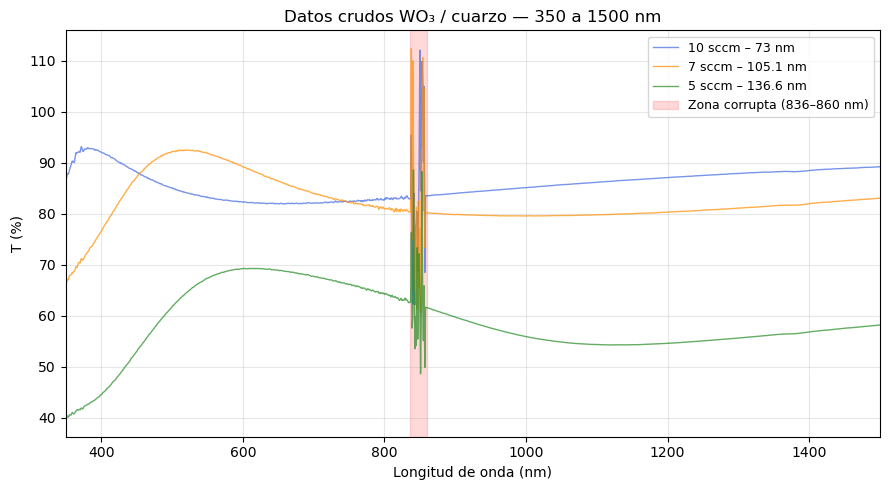

In [4]:
# Gráfica datos crudos – rango de trabajo
fig, ax = plt.subplots(figsize=(9, 5))

for name, info in SAMPLES.items():
    wl = raw_data[name]["wl"]
    T  = raw_data[name]["T"]
    m  = (wl >= 350) & (wl <= 1500)
    ax.plot(wl[m], T[m]*100, color=info["color"], alpha=0.7,
            linewidth=1, label=info["label"])

ax.axvspan(BAD_MIN, BAD_MAX, color="red", alpha=0.15,
           label=f"Zona corrupta ({BAD_MIN}–{BAD_MAX} nm)")
ax.set_xlabel("Longitud de onda (nm)")
ax.set_ylabel("T (%)")
ax.set_title("Datos crudos WO₃ / cuarzo — 350 a 1500 nm")
ax.set_xlim(350, 1500)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Eliminación de zona corrupta + Filtro S-G + Guardado

El archivo dat se guarda con el **rango completo (250–2000 nm)** — PUMA recorta internamente.

In [5]:
def remove_and_interpolate(wl, T):
    """Elimina zona corrupta e interpola con PCHIP usando vecinos ±100 nm."""
    mask_good  = (wl < BAD_MIN) | (wl > BAD_MAX)
    wl_good, T_good = wl[mask_good], T[mask_good]
    margin     = 100
    mask_local = (wl_good >= BAD_MIN - margin) & (wl_good <= BAD_MAX + margin)
    interp     = PchipInterpolator(wl_good[mask_local], T_good[mask_local])
    wl_gap     = np.arange(BAD_MIN, BAD_MAX + 1, 1.0)
    T_gap      = np.clip(interp(wl_gap), 0.0, 1.0)
    wl_out     = np.concatenate([wl_good, wl_gap])
    T_out      = np.concatenate([T_good,  T_gap])
    idx        = np.argsort(wl_out)
    return wl_out[idx], T_out[idx]


def save_puma_dat(wl, T, fname_base, output_dir):
    """Guarda rango completo en formato PUMA con notación científica."""
    T_clipped = np.clip(T, 0.0, 1.0)
    n_obs     = len(wl)
    outpath   = os.path.join(output_dir, f"{fname_base}-dat.txt")
    with open(outpath, "w") as f:
        f.write(f"{n_obs}\n")
        np.savetxt(f, np.column_stack([wl, T_clipped]), fmt="%.3e")
    size_kb = os.path.getsize(outpath) / 1024
    print(f"  ✓  {os.path.basename(outpath)}  |  {n_obs} puntos | "
          f"λ = {wl.min():.0f}–{wl.max():.0f} nm | {size_kb:.1f} kB")
    return outpath


clean_data    = {}
filtered_data = {}
puma_files    = {}

print(f"Procesando → {os.path.abspath(DIR_FILTRADO)}/\n")
for name, info in SAMPLES.items():
    wl_raw, T_raw = raw_data[name]["wl"], raw_data[name]["T"]
    wl_cl, T_cl   = remove_and_interpolate(wl_raw, T_raw)
    clean_data[name] = {"wl": wl_cl, "T": T_cl}
    T_sg = np.clip(savgol_filter(T_cl, window_length=SG_WINDOW, polyorder=SG_POLY), 0.0, 1.0)
    filtered_data[name] = {"wl": wl_cl, "T": T_sg}
    path = save_puma_dat(wl_cl, T_sg, name, DIR_FILTRADO)
    puma_files[name] = path

print("\nArchivos en WO3_filtrado/:")
for fname in sorted(os.listdir(DIR_FILTRADO)):
    if fname.endswith(".txt"):
        print(f"  {fname}")

primer = puma_files[list(SAMPLES.keys())[0]]
print(f"\nPrimeras 5 líneas de {os.path.basename(primer)}:")
with open(primer) as f:
    for i, line in enumerate(f):
        print(" ", line.rstrip())
        if i == 5: break

Procesando → c:\Users\Gabo\Computacional\LabAvanzadoII\WO3\WO3_filtrado/

  ✓  WO3_S2_10sccm-dat.txt  |  1751 puntos | λ = 250–2000 nm | 35.9 kB
  ✓  WO3_S5_7sccm-dat.txt  |  1751 puntos | λ = 250–2000 nm | 35.9 kB
  ✓  WO3_S8_5sccm-dat.txt  |  1751 puntos | λ = 250–2000 nm | 35.9 kB

Archivos en WO3_filtrado/:
  WO3_S2_10sccm-dat.txt
  WO3_S5_7sccm-dat.txt
  WO3_S8_5sccm-dat.txt

Primeras 5 líneas de WO3_S2_10sccm-dat.txt:
  1751
  2.500e+02 7.330e-02
  2.510e+02 7.427e-02
  2.520e+02 7.539e-02
  2.530e+02 7.668e-02
  2.540e+02 7.812e-02


## 3. Comparación: crudo vs filtrado

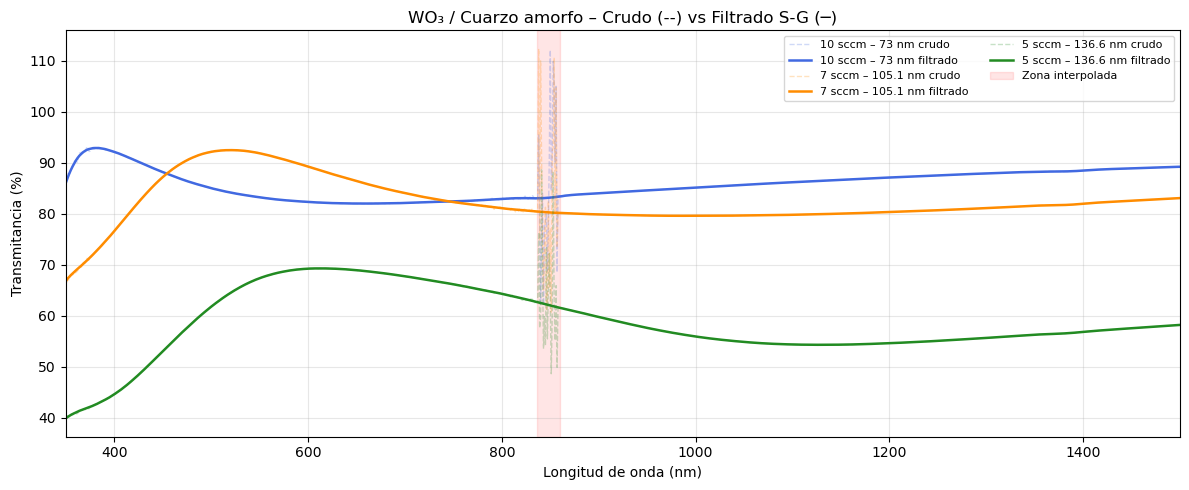

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, info in SAMPLES.items():
    wl_r = raw_data[name]["wl"]
    T_r  = raw_data[name]["T"]
    wl_f = filtered_data[name]["wl"]
    T_f  = filtered_data[name]["T"]
    mr   = (wl_r >= 350) & (wl_r <= 1500)
    mf   = (wl_f >= 350) & (wl_f <= 1500)
    ax.plot(wl_r[mr], T_r[mr]*100, color=info["color"], alpha=0.25, linewidth=1,
            linestyle="--", label=f"{info['label']} crudo")
    ax.plot(wl_f[mf], T_f[mf]*100, color=info["color"], alpha=1.0, linewidth=1.8,
            label=f"{info['label']} filtrado")
ax.axvspan(BAD_MIN, BAD_MAX, color="red", alpha=0.10, label="Zona interpolada")
ax.set_xlabel("Longitud de onda (nm)")
ax.set_ylabel("Transmitancia (%)")
ax.set_title("WO₃ / Cuarzo amorfo – Crudo (--) vs Filtrado S-G (─)")
ax.set_xlim(350, 1500)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Estrategia de runs PUMA

Cada run refina al anterior usando `INIT=9` (parte del `-sol.txt` previo).
Parámetros comunes: `NLAYERS=4`, `SLAYER=2`, `SUBSTRATE=60` (cuarzo amorfo, Malitson 1965), `LMIN=300 nm`, `LMAX=1500 nm`.

| Run | INIT | maxIT | Espesor | Inflexión | NOBS | Propósito |
|-----|------|-------|---------|-----------|------|-----------|
| 1 | 0 | 3 000 | ±20%, paso 5 nm | 340–460, paso 20 | 175 | Barrido amplio |
| 2 | 9 | 5 000 | ±7%, paso 1 nm | 340–460, paso 20 | 175 | Refinamiento |
| 3 | 9 | 50 000 | fijo (d_run2) | fija (inf_run2) | 100/125/175 | Ajuste fino |

> **Nota:** los runs P1–P6 usaron `LMIN=350 nm`, cortando el borde de absorción del WO₃ (Eg ≈ 2.9–3.1 eV). Archivados en `WO3_result_PUMA/S*/pruebas/`.

## Tabla de parámetros – First Call (referencia)

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `NLAYERS` | 4 | aire / WO₃ / cuarzo / aire |
| `SLAYER` | 2 | capa sustrato = cuarzo |
| `SUBSTRATE` | **60** | cuarzo amorfo / fused silica — Malitson 1965 (corregido en `puma_mod.c`) |
| `DATATYPE` | T | transmitancia |
| `NOBS` | 100 | puntos equiespaciados para el ajuste |
| `LAMBDAmin` | 300 nm | por debajo WO₃ absorbe fuerte (T < 10%) |
| `LAMBDAmax` | 1500 nm | límite del modelo de cuarzo en PUMA |
| `maxIT` | 3000 | balance entre convergencia y tiempo de cluster |
| `QUAD` | 1e+100 | sin cota de error (first call) |
| `INIT` | 0 | estimación inicial desde cero |
| `THICKNESSstep` | 2 nm | paso grueso para first call |
| `INFLEstep` | 100 nm | exploración gruesa del punto de inflexión |
| `N0ini/fin` | 1.90 / 2.50 | n en λ_min; extendido a 1.90 (±15% sobre n≈2.2) |
| `NFini/fin` | 1.80 / 2.20 | n en λ_max — WO₃ literatura |
| `N0/NFstep` | 0.10 | **paso grueso** (vs 0.05 del ITO) |
| `K0ini/fin` | 0.25 / 0.55 | k≈0.45 en 300 nm (Fig. 4.3a) ±15%; k→0 en 1500 nm |
| `K0step` | 0.05 | 7 valores: 0.25, 0.30, …, 0.55 |

> **Antes de lanzar:** recompilar `puma_mod.c` en el cluster con `gcc -O4 -lm puma_mod.c -o puma_mod`  
> **Después del first call:** revisar `FNAME-inf.txt`, anotar espesor, inflexión y error cuadrático,  
> y afinar con second call (`INIT=9`, paso más fino, `maxIT=5000`)

## 5. Resultados PUMA – Análisis de `-inf.txt`

Copia los archivos `*-inf.txt` del cluster a la carpeta `WO3_result_PUMA/` antes de correr esta sección.

Para cada muestra se extraen:
- **n(λ)** y **k(λ)** de la sección `REFRACTIVE INDICES AND ABSORPTION`
- **T simulada** de la sección `TRANSMITTANCE WITH THE ESTIMATED`

y se comparan contra los datos experimentales filtrados en el mismo rango que la simulación.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter
from scipy.interpolate import PchipInterpolator, interp1d
import os
import glob

# ── CARGAR RESULTADOS PUMA ─────────────────────────────────────────────────────
# Estructura esperada:
#   WO3_result_PUMA/
#     S2/  WO3_S2_10sccm-inf_run1_175, run2_175, run3_100, run3_125, run3_175
#     S5/  WO3_S5_7sccm-inf_run1_175,  run2_175, run3_100, run3_125, run3_150, run3_175

SAMPLES_RESULTS = {
    "WO3_S2_10sccm": os.path.join(DIR_RESULTS, "S2"),
    "WO3_S5_7sccm" : os.path.join(DIR_RESULTS, "S5"),
}

def parse_puma_inf(filepath):
    """
    Lee un archivo PUMA *-inf.txt y extrae n(λ), k(λ), T_sim(λ),
    espesor, inflexión y QE.
    """
    if not os.path.exists(filepath):
        return None

    block_nk, block_t = [], []
    section   = None
    thickness = inflexion = qe = None

    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            ls = line.strip()
            if "Thickness of film 1" in ls:
                try: thickness = float(ls.split("=")[-1].strip().split()[0])
                except: pass
            if "Inflexion point" in ls:
                try: inflexion = float(ls.split("=")[-1].strip().split()[0])
                except: pass
            if "QUADRATIC ERROR" in ls:
                try: qe = float(ls.split("=")[-1].strip())
                except: pass
            if "REFRACTIVE INDICES AND ABSORPTION" in ls:
                section = "nk"; continue
            if "TRANSMITTANCE WITH THE ESTIMATED" in ls:
                section = "t"; continue
            if not ls or ls.startswith("lambda") or ls.startswith("Film"):
                continue
            try:
                vals = list(map(float, ls.split()))
                if section == "nk" and len(vals) == 3:
                    block_nk.append(vals)
                elif section == "t" and len(vals) == 2:
                    block_t.append(vals)
            except ValueError:
                continue

    if not block_nk or not block_t:
        print(f"  ⚠  {os.path.basename(filepath)}: secciones incompletas")
        return None

    nk = np.array(block_nk)
    t  = np.array(block_t)
    return {
        "wl_nk": nk[:,0], "n": nk[:,1], "k": nk[:,2],
        "wl_t" : t[:,0],  "T_sim": t[:,1],
        "thickness": thickness, "inflexion": inflexion,
        "qe": qe, "filepath": filepath,
    }


def escanear_resultados(sample, folder):
    """
    Busca archivos con patrón {sample}-inf_run*.
    Extrae etiqueta run (ej. 'run1_175', 'run3_100').
    Excluye subcarpeta pruebas/.
    """
    patron  = os.path.join(folder, f"{sample}-inf_run*")
    archivos = sorted(glob.glob(patron))

    resultados = {}
    for fp in archivos:
        if "pruebas" in fp:
            continue
        etiqueta = os.path.basename(fp).replace(f"{sample}-inf_", "")
        res = parse_puma_inf(fp)
        if res is not None:
            resultados[etiqueta] = res
    return resultados


# ── CARGAR ────────────────────────────────────────────────────────────────────
print("Escaneando resultados PUMA...\n")
puma_results = {}

for sample, folder in SAMPLES_RESULTS.items():
    pruebas = escanear_resultados(sample, folder)
    if not pruebas:
        print(f"  –  {sample}: sin archivos en {folder}/")
        continue
    puma_results[sample] = pruebas
    print(f"  {sample}:")
    for etiqueta, res in pruebas.items():
        d   = f"{res['thickness']:.1f} nm" if res['thickness'] else "?"
        inf = f"{res['inflexion']:.0f} nm" if res['inflexion'] else "?"
        qe  = f"{res['qe']:.2e}"           if res['qe']       else "?"
        print(f"    [{etiqueta}]  d={d}  inflexión={inf}  QE={qe}")

print(f"\nTotal muestras cargadas: {len(puma_results)}")

Escaneando resultados PUMA...

  WO3_S2_10sccm:
    [run1_175]  d=95.0 nm  inflexión=350 nm  QE=4.00e-05
    [run2_125]  d=95.0 nm  inflexión=350 nm  QE=2.90e-05
    [run2_175]  d=95.0 nm  inflexión=350 nm  QE=1.04e-05
    [run3_100]  d=95.0 nm  inflexión=350 nm  QE=2.65e-05
    [run3_125]  d=95.0 nm  inflexión=350 nm  QE=2.90e-05
    [run3_150]  d=95.0 nm  inflexión=350 nm  QE=8.76e-06
    [run3_175]  d=95.0 nm  inflexión=350 nm  QE=1.04e-05
  WO3_S5_7sccm:
    [run1_125]  d=130.0 nm  inflexión=350 nm  QE=7.29e-05
    [run1_175]  d=130.0 nm  inflexión=350 nm  QE=1.01e-04
    [run2_175]  d=131.0 nm  inflexión=350 nm  QE=8.26e-05
    [run3_100]  d=131.0 nm  inflexión=330 nm  QE=5.03e-05
    [run3_125]  d=131.0 nm  inflexión=350 nm  QE=5.87e-05
    [run3_150]  d=131.0 nm  inflexión=350 nm  QE=6.96e-05
    [run3_175]  d=131.0 nm  inflexión=350 nm  QE=8.15e-05

Total muestras cargadas: 2


In [10]:
# ── CONFIGURACIÓN ─────────────────────────────────────────────────────────────
hc_eV_nm = 1239.84  # eV·nm

SAMPLE_INFO = {
    "WO3_S2_10sccm": {"color": "steelblue",  "label": "S2 — 10 sccm O₂"},
    "WO3_S5_7sccm" : {"color": "darkorange", "label": "S5 — 7 sccm O₂"},
}

EXP_FILES = {
    "WO3_S2_10sccm": os.path.join(DIR_FILTRADO, "WO3_S2_10sccm-dat.txt"),
    "WO3_S5_7sccm" : os.path.join(DIR_FILTRADO, "WO3_S5_7sccm-dat.txt"),
}

# Selección de runs a graficar — [] = todos los disponibles para esa muestra
GRAFICAR = {
    "WO3_S2_10sccm": ["run3_100", "run3_125", "run3_150", "run3_175"],
    "WO3_S5_7sccm" : ["run3_100", "run3_125", "run3_150", "run3_175"],
}

# Estilos de línea por etiqueta run3
NOBS_STYLES = {
    "run3_100": (":",  0.8),
    "run3_125": ("--", 1.2),
    "run3_150": ("-.", 1.5),
    "run3_175": ("-",  2.0),
}

# ── FILTRAR ────────────────────────────────────────────────────────────────────
resultados_plot = {}
for sample, runs_sel in GRAFICAR.items():
    if sample not in puma_results:
        print(f"  ? {sample} no encontrado en puma_results")
        continue
    filtradas = {e: r for e, r in puma_results[sample].items()
                 if not runs_sel or e in runs_sel}
    if filtradas:
        resultados_plot[sample] = filtradas
    else:
        print(f"  ? {sample}: ninguno de {runs_sel} encontrado "
              f"(disponibles: {list(puma_results[sample].keys())})")

# ── CARGAR EXPERIMENTALES ──────────────────────────────────────────────────────
filtered_data = {}
for sample, path in EXP_FILES.items():
    if os.path.exists(path):
        d = np.loadtxt(path, skiprows=1)
        filtered_data[sample] = {"wl": d[:, 0], "T": d[:, 1]}
    else:
        print(f"  ? Experimental no encontrado: {path}")

In [11]:
# ── FUNCIONES DE GRAFICACIÓN ──────────────────────────────────────────────────
# Runs finales seleccionados por muestra
MEJOR_RUN = {
    "WO3_S2_10sccm": "run3_150",  # menor error numérico
    "WO3_S5_7sccm" : "run3_175",  # más físicamente consistente
}

def mejor_run3(sample):
    return MEJOR_RUN.get(sample, None)

def plot_nk(ax_n, ax_k, sample, etiqueta, res, info, ls="-", lw=2.0, label=None):
    lbl = label or info["label"]
    ax_n.plot(res["wl_nk"], res["n"],
              color=info["color"], linewidth=lw, linestyle=ls, label=lbl)
    k = res["k"].copy()
    k_valid = k[k > 1e-8]
    if len(k_valid) == 0:
        # k indetectable — graficar línea fantasma solo para que aparezca en leyenda
        ax_k.plot([], [], color=info["color"], linewidth=lw,
                  linestyle=ls, label=f"{lbl} (k ≈ 0)")
    else:
        k[k < 1e-8] = np.nan
        ax_k.plot(res["wl_nk"], k,
                  color=info["color"], linewidth=lw, linestyle=ls, label=lbl)

def plot_n_only(ax, sample, etiqueta, res, info, ls="-", lw=2.0, label=None):
    lbl = label or info["label"]
    ax.plot(res["wl_nk"], res["n"],
            color=info["color"], linewidth=lw, linestyle=ls, label=lbl)

def plot_T(ax, sample, etiqueta, res, info):
    lam_lo, lam_hi = res["wl_t"].min(), res["wl_t"].max()
    if sample in filtered_data:
        wl_exp = filtered_data[sample]["wl"]
        T_exp  = filtered_data[sample]["T"]
        mask   = (wl_exp >= lam_lo) & (wl_exp <= lam_hi)
        wl_exp, T_exp = wl_exp[mask], T_exp[mask]
        T_sim_i = interp1d(res["wl_t"], res["T_sim"],
                           kind="linear", bounds_error=False,
                           fill_value="extrapolate")(wl_exp)
        rmse = np.sqrt(np.mean((T_sim_i - T_exp)**2))
        mape = np.mean(np.abs(T_sim_i - T_exp) / np.clip(T_exp, 1e-6, None)) * 100
        ax.plot(wl_exp, T_exp*100, color=info["color"],
                linewidth=1.5, alpha=0.7, label="Experimental")
        subtitulo = (f"{info['label']}  |  d = {res['thickness']:.0f} nm  "
                     f"RMSE = {rmse*100:.3f}%  MAPE = {mape:.2f}%")
    else:
        subtitulo = f"{info['label']}  |  d = {res['thickness']:.0f} nm"
    ax.plot(res["wl_t"], res["T_sim"]*100, color="black",
            linewidth=2, linestyle="--", label="PUMA simulada")
    ax.set_xlabel("λ (nm)", fontsize=12)
    ax.set_ylabel("T (%)", fontsize=12)
    ax.set_title(subtitulo, fontsize=10)
    ax.set_xlim(lam_lo, lam_hi)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

def setup_nk_axes(ax_n, ax_k):
    ax_n.set_xlabel("λ (nm)", fontsize=12)
    ax_n.set_ylabel("n", fontsize=12)
    ax_n.set_xlim(LAMBDA_MIN_PUMA, LAMBDA_MAX_PUMA)
    ax_n.legend(fontsize=10)
    ax_n.grid(True, alpha=0.3)
    ax_k.set_xlabel("λ (nm)", fontsize=12)
    ax_k.set_ylabel("k", fontsize=12)
    ax_k.set_yscale("log")
    ax_k.set_xlim(LAMBDA_MIN_PUMA, LAMBDA_MAX_PUMA)
    ax_k.legend(fontsize=10)
    ax_k.grid(True, alpha=0.3, which="both")

def setup_n_axis(ax):
    ax.set_xlabel("λ (nm)", fontsize=12)
    ax.set_ylabel("n", fontsize=12)
    ax.set_xlim(LAMBDA_MIN_PUMA, LAMBDA_MAX_PUMA)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

def tauc_plot(ax, resultados_plot, SAMPLE_INFO, hc_eV_nm, potencia, ylabel):
    hnu_min_all, hnu_max_all = np.inf, -np.inf

    EG_RANGES = {
        "WO3_S2_10sccm": (2.25, 3.50),
        "WO3_S5_7sccm" : (2.25, 3.50),
    }

    for sample, pruebas in resultados_plot.items():
        info = SAMPLE_INFO.get(sample, {"color": "gray", "label": sample})
        for etiqueta, res in pruebas.items():
            wl = res["wl_nk"]
            k  = res["k"]

            mask_all = k > 1e-8
            if not mask_all.any():
                print(f"  {info['label']} [{etiqueta}]: k ≈ 0 — omitido del Tauc")
                continue

            wl_all    = wl[mask_all]
            k_all     = k[mask_all]
            hnu_all   = hc_eV_nm / wl_all
            alpha_all = 4 * np.pi * k_all / (wl_all * 1e-7)
            tauc_all  = (alpha_all * hnu_all) ** potencia

            idx      = np.argsort(hnu_all)
            hnu_all  = hnu_all[idx]
            tauc_all = tauc_all[idx]

            hnu_min_all = min(hnu_min_all, hnu_all.min())
            hnu_max_all = max(hnu_max_all, hnu_all.max())

            label = f"{info['label']} [{etiqueta}]" if len(pruebas) > 1 else info["label"]
            ax.plot(hnu_all, tauc_all, color=info["color"],
                    linewidth=2.0, linestyle="-", label=label)

            # ── Ajuste lineal en rango manual ─────────────────────────────────
            mask_lin = k[mask_all][idx] > 1e-6
            hnu_lin  = hnu_all[mask_lin]
            tauc_lin = tauc_all[mask_lin]
            if not mask_lin.any():
                continue

            rango    = EG_RANGES.get(sample, (2.25, 3.50))
            lin_mask = (hnu_lin >= rango[0]) & (hnu_lin <= rango[1])

            if lin_mask.sum() < 3:
                print(f"  {info['label']} [{etiqueta}]: sin puntos en "
                      f"rango {rango} — omitido")
                continue

            coeffs = np.polyfit(hnu_lin[lin_mask], tauc_lin[lin_mask], 1)
            poly   = np.poly1d(coeffs)
            Eg     = -coeffs[1] / coeffs[0]

            if not (0.5 < Eg < 5.0):
                print(f"  {info['label']} [{etiqueta}]: "
                      f"Eg fuera de rango ({Eg:.2f} eV) — omitido")
                continue

            hnu_line = np.linspace(Eg, hnu_lin[lin_mask].max(), 100)
            ax.plot(hnu_line, poly(hnu_line), color=info["color"],
                    linewidth=1.8, linestyle="-", alpha=0.85)
            ax.plot(Eg, 0, "o", color=info["color"], markersize=7, zorder=5)
            ax.axvline(Eg, color=info["color"], linewidth=1.0,
                       linestyle=":", alpha=0.6)
            ax.text(Eg + 0.03, tauc_lin.max() * 0.90,
                    f"$E_g$ = {Eg:.2f} eV",
                    fontsize=11, color=info["color"], va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                              edgecolor=info["color"], alpha=0.7))
            tipo = "indirecto" if potencia == 0.5 else "directo"
            print(f"  [{tipo}] {info['label']} [{etiqueta}]: "
                  f"Eg = {Eg:.2f} eV  ({hc_eV_nm/Eg:.0f} nm)")

    if np.isfinite(hnu_min_all) and np.isfinite(hnu_max_all):
        margen = (hnu_max_all - hnu_min_all) * 0.08
        ax.set_xlim(hnu_min_all - margen * 2, hnu_max_all + margen)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlabel(r"$h\nu$ (eV)", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

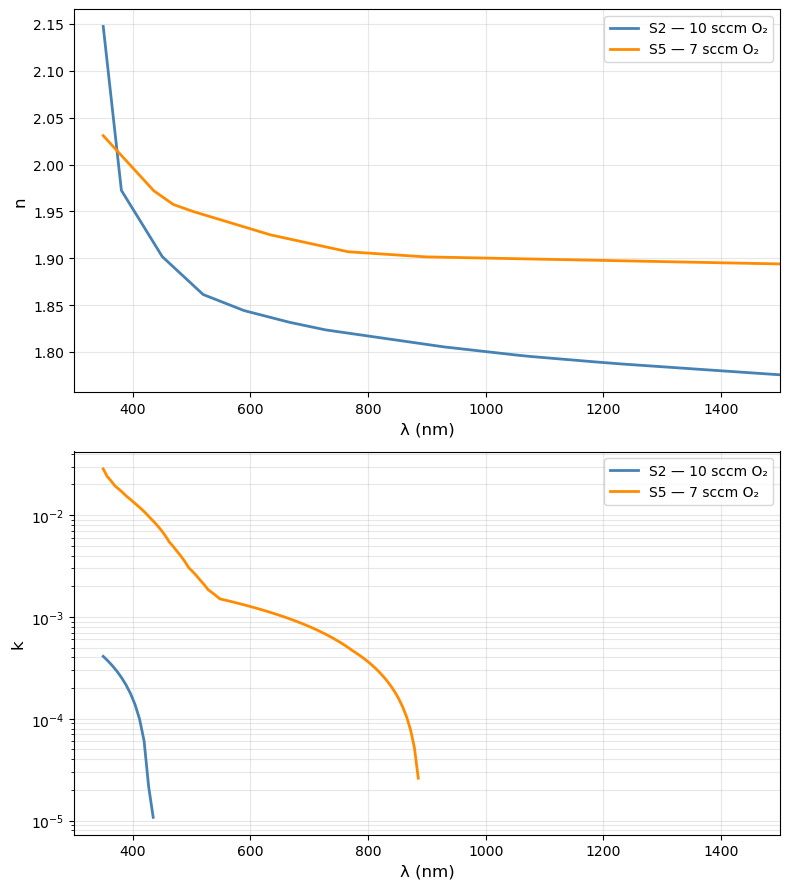

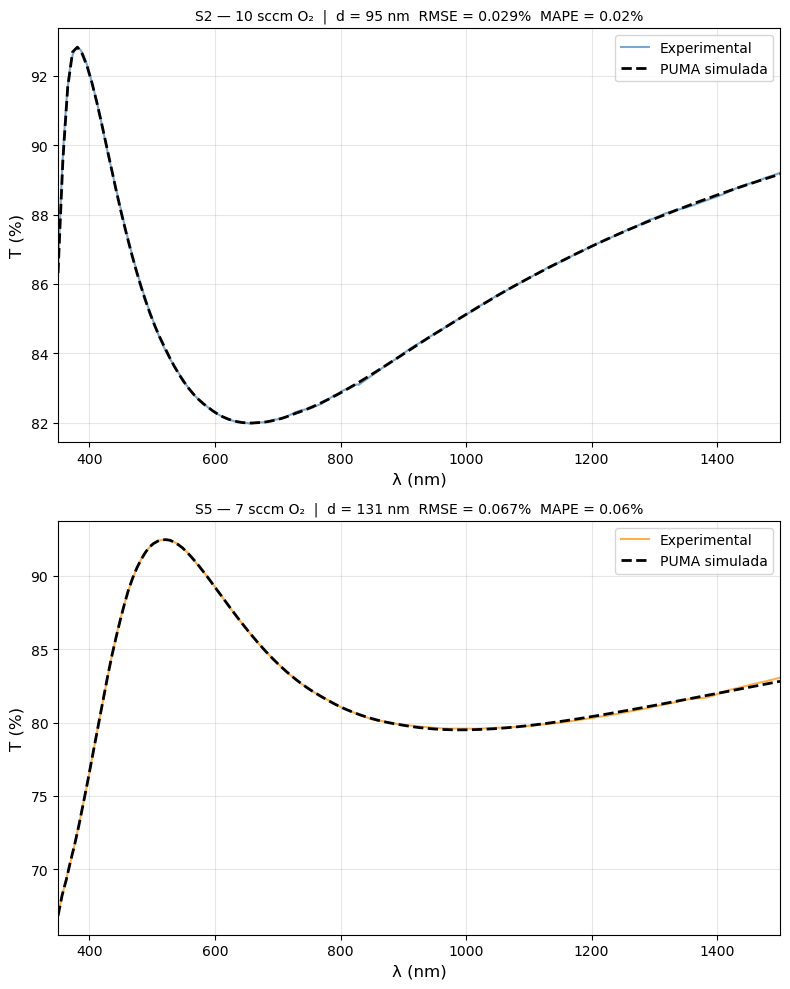

Band gap — S2 vs S5:
  [indirecto] S2 — 10 sccm O₂ [run3_150]: Eg = 2.72 eV  (457 nm)
  [indirecto] S5 — 7 sccm O₂ [run3_175]: Eg = 2.10 eV  (589 nm)


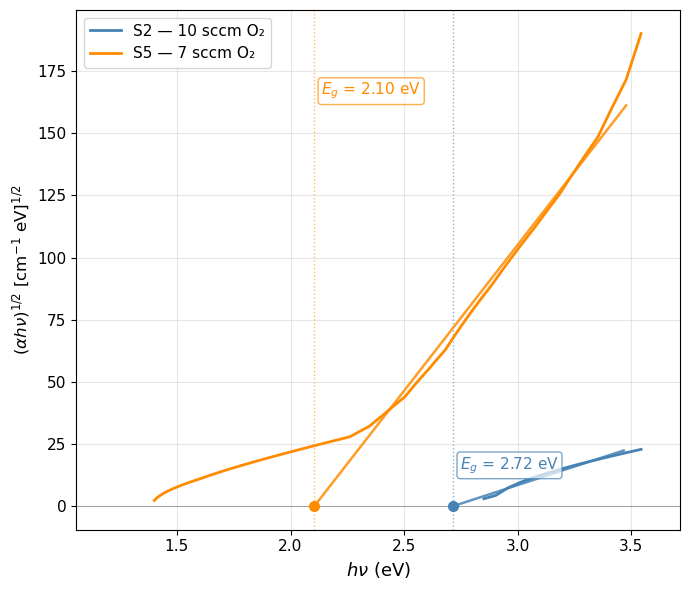

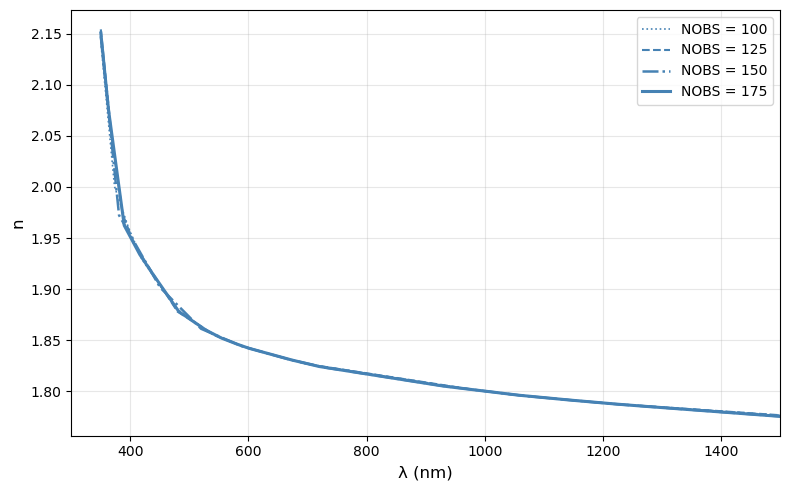

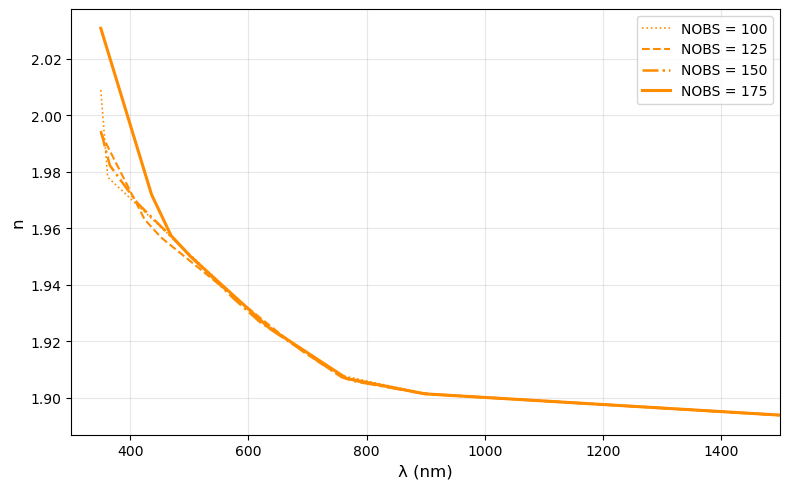

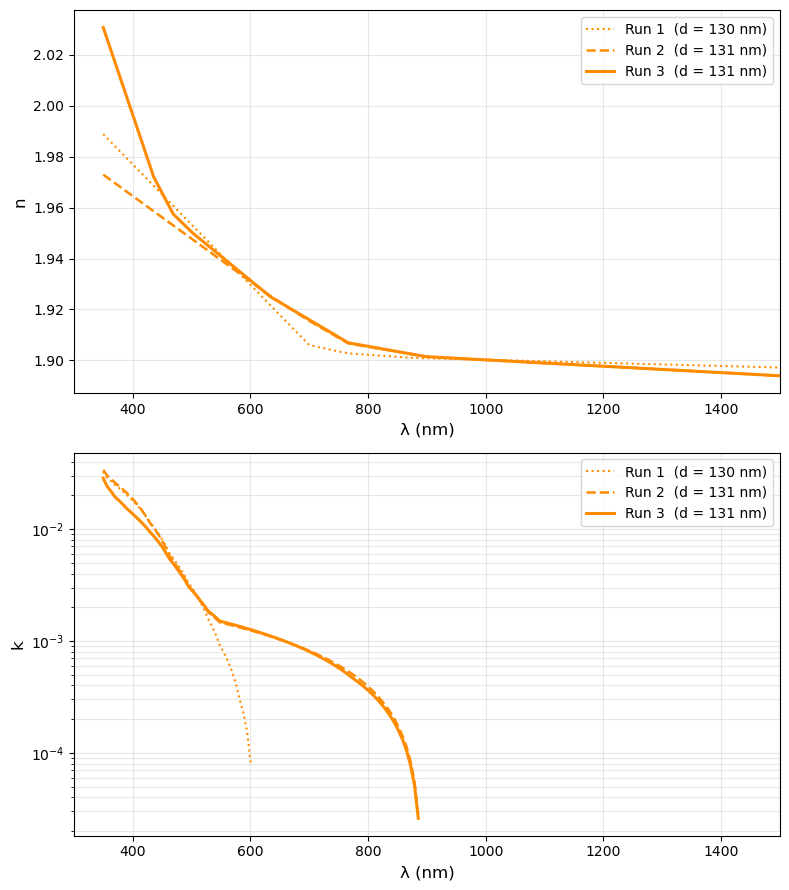

In [12]:
# ── GRÁFICAS ──────────────────────────────────────────────────────────────────
NOBS_STYLES = {
    "run3_100": (":",  1.2),
    "run3_125": ("--", 1.5),
    "run3_150": ("-.", 1.8),
    "run3_175": ("-",  2.2),
}

run_S2 = mejor_run3("WO3_S2_10sccm")
run_S5 = mejor_run3("WO3_S5_7sccm")

# ── 1. n(λ) y k(λ) — S2 vs S5 ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 9))
for sample, run in [("WO3_S2_10sccm", run_S2), ("WO3_S5_7sccm", run_S5)]:
    if run is None: continue
    plot_nk(axes[0], axes[1], sample, run,
            resultados_plot[sample][run], SAMPLE_INFO[sample])
setup_nk_axes(axes[0], axes[1])
plt.tight_layout()
plt.savefig(os.path.join("Imagenes", "nk_S2vsS5.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# ── 2. T experimental vs simulada — S2 vs S5 ─────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 10), squeeze=False)
for row, (sample, run) in enumerate([("WO3_S2_10sccm", run_S2),
                                      ("WO3_S5_7sccm",  run_S5)]):
    if run is None: continue
    plot_T(axes[row, 0], sample, run,
           resultados_plot[sample][run], SAMPLE_INFO[sample])
plt.tight_layout()
plt.savefig(os.path.join("Imagenes", "T_S2vsS5.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# ── 3. Tauc plot indirecto — S2 vs S5 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
resultados_tauc1 = {s: {r: resultados_plot[s][r]}
                    for s, r in [("WO3_S2_10sccm", run_S2),
                                 ("WO3_S5_7sccm",  run_S5)]
                    if r is not None}
print("Band gap — S2 vs S5:")
tauc_plot(ax, resultados_tauc1, SAMPLE_INFO, hc_eV_nm,
          potencia=0.5,
          ylabel=r"$(\alpha h\nu)^{1/2}\ [\mathrm{cm}^{-1}\ \mathrm{eV}]^{1/2}$")
plt.tight_layout()
plt.savefig(os.path.join("Imagenes", "tauc_S2vsS5.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# ── 4. Convergencia NOBS en run3 — solo n(λ) ─────────────────────────────────
for sample in ["WO3_S2_10sccm", "WO3_S5_7sccm"]:
    info  = SAMPLE_INFO[sample]
    runs3 = sorted([e for e in resultados_plot.get(sample, {})
                    if e.startswith("run3_")],
                   key=lambda e: int(e.split("_")[-1]))
    if not runs3: continue
    fig, ax = plt.subplots(figsize=(8, 5))
    for etiqueta in runs3:
        res    = resultados_plot[sample][etiqueta]
        ls, lw = NOBS_STYLES.get(etiqueta, ("-", 1.5))
        nobs   = etiqueta.split("_")[-1]
        plot_n_only(ax, sample, etiqueta, res, info,
                    ls=ls, lw=lw, label=f"NOBS = {nobs}")
    setup_n_axis(ax)
    plt.tight_layout()
    fname = f"convergencia_nobs_{sample.split('_')[1]}.pdf"
    plt.savefig(os.path.join("Imagenes", fname), bbox_inches="tight", dpi=300)
    plt.show()

# ── 5. Cadena completa S5: run1_175 → run2_175 → run3_175 ────────────────────
sample_cadena = "WO3_S5_7sccm"
cadena_runs   = ["run1_175", "run2_175", "run3_175"]
cadena_styles = {
    "run1_175": (":",  1.5),
    "run2_175": ("--", 1.8),
    "run3_175": ("-",  2.2),
}
disponibles = {e: puma_results[sample_cadena][e]
               for e in cadena_runs
               if e in puma_results.get(sample_cadena, {})}

if disponibles:
    info = SAMPLE_INFO[sample_cadena]
    fig, axes = plt.subplots(2, 1, figsize=(8, 9))
    for etiqueta, res in disponibles.items():
        ls, lw    = cadena_styles[etiqueta]
        run_label = etiqueta.replace("_175", "").replace("run", "Run ")
        plot_nk(axes[0], axes[1], sample_cadena, etiqueta, res, info,
                ls=ls, lw=lw,
                label=f"{run_label}  (d = {res['thickness']:.0f} nm)")
    setup_nk_axes(axes[0], axes[1])
    plt.tight_layout()
    plt.savefig(os.path.join("Imagenes", "cadena_S5_run1_run2_run3.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()
else:
    print(f"Faltan runs: {list(puma_results.get(sample_cadena, {}).keys())}")